# Noise Busters — our run (ibm_fez)
Reuses finished QPU job IDs from `job_ids.json`; running this notebook spends **no** QPU time. See README.md for the method.

In [1]:
from common import *
import json
jobs = load_jobs(); jobs

{'backend': 'ibm_fez',
 'baseline': 'db5b02clf4us73c3pu4g',
 'noise_learning': 'db5b02g4qg6s73c37oq0',
 'executor_fwd': 'db5cg0cvf2bc73cvn940',
 'executor_mirror': 'db5cg0kvf2bc73cvn970',
 'estimator_zne': 'db5cgao4qg6s73c39h30',
 'executor_fwd_2': 'db5cpucvf2bc73cvnjk0'}

## Problem definition (fixed, from the main prompt)

In [2]:
print(circuit.num_qubits, 'qubits, depth', circuit.depth(), ',', circuit.count_ops().get('cz'), 'CZ')
print('observable:', observable.paulis[0])
from qiskit.quantum_info import Statevector
print('exact (noiseless statevector) <Z6Z7> =', Statevector(circuit).expectation_value(observable).real)

15 qubits, depth 40 , 112 CZ
observable: IIIIIIIZZIIIIII
exact (noiseless statevector) <Z6Z7> = 0.6953124999999983


## Transpile + box: 17 boxes, 3 unique layers (shared by forward and mirror circuits)

In [3]:
exec(open('prep.py').read())

backend: ibm_fez
layout: [111, 110, 109, 108, 107, 106, 105, 117, 125, 124, 123, 136, 143, 142, 141]
fwd: boxes=17, unique layers=3
mirror: boxes=33, unique layers=3


## QPU usage of each job

In [4]:
for k, v in jobs.items():
    if k != 'backend':
        j = service.job(v); print(f'{k:16s} {v}  {j.status()}  usage={j.usage()}s')

baseline         db5b02clf4us73c3pu4g  DONE  usage=5s


noise_learning   db5b02g4qg6s73c37oq0  DONE  usage=86s


executor_fwd     db5cg0cvf2bc73cvn940  DONE  usage=21s


executor_mirror  db5cg0kvf2bc73cvn970  DONE  usage=21s


estimator_zne    db5cgao4qg6s73c39h30  DONE  usage=27s


executor_fwd_2   db5cpucvf2bc73cvnjk0  DONE  usage=39s


## Post-processing (TREX, post-selection, SLC gamma rescaling)

In [5]:
exec(open('postprocess.py').read())

baseline         0.5758
fwd_raw          (0.56817626953125, 0.004545961190462252)
fwd_trex         (0.6365457940573506, 0.008418533944245837)
fwd_slc          (0.7240890169640241, 0.016172886771687062)
fwd_slc_edge     (0.7086743533232649, 0.009590336859329848)
mirror_raw       (0.6480712890625, 0.004207173077826634)
mirror_trex      (0.7597162850005784, 0.007908318969472163)
mirror_slc       (0.6966152782956208, 0.048274927906901674)
mirror_slc_edge  (0.6781373422601806, 0.026519321395112302)


## Comparison

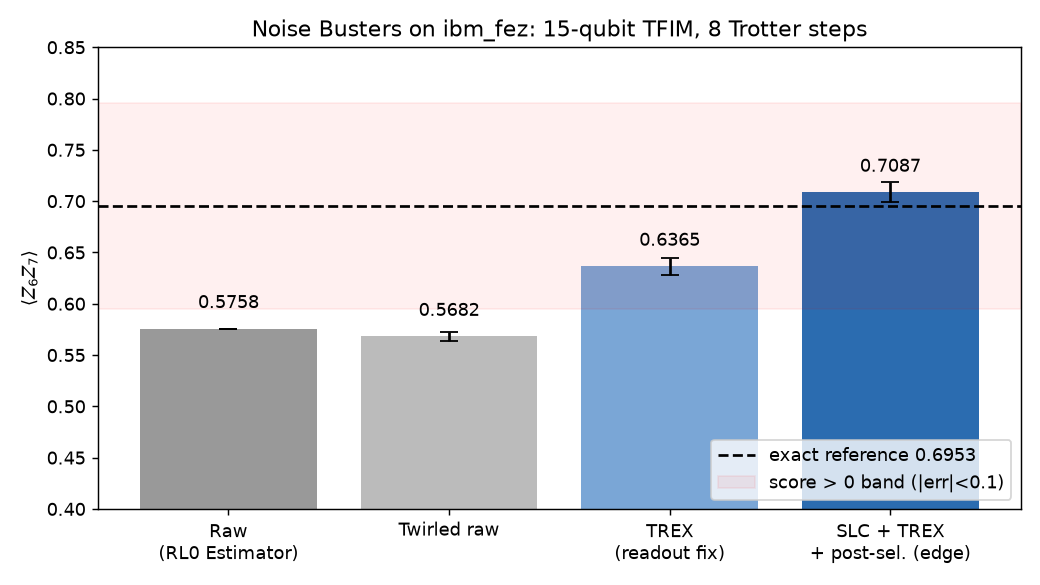

In [6]:
from IPython.display import Image
Image('figs/results.png')

## Run 2: same SLC pipeline, 512 randomizations × 128 shots (job `executor_fwd_2`)

In [7]:
exec(open('postprocess2.py').read())

baseline         0.5758
fwd_raw          (0.5655517578125, 0.0032215343909888787)
fwd_trex         (0.6293627213041724, 0.007026063425847316)
fwd_slc          (0.696523163586833, 0.013402791333362404)
fwd_slc_edge     (0.6871297378702305, 0.006842029855420461)


## Final estimate: inverse-variance average of run 1 and run 2
The averaging rule was fixed before seeing the grader result for the combined value.

In [8]:
import json, numpy as np
a = json.load(open('results.json'))['fwd_slc_edge']; b = json.load(open('results2.json'))['fwd_slc_edge']
w = np.array([1/a[1]**2, 1/b[1]**2])
final_value = float((w @ [a[0], b[0]]) / w.sum()); final_err = float(1/np.sqrt(w.sum()))
print(f'run 1 = {a[0]:.4f} ± {a[1]:.4f}')
print(f'run 2 = {b[0]:.4f} ± {b[1]:.4f}')
print(f'final = {final_value:.4f} ± {final_err:.4f}')

run 1 = 0.7087 ± 0.0096
run 2 = 0.6871 ± 0.0068
final = 0.6944 ± 0.0056


## Submit to the grader

In [9]:
from qc_grader.challenges.fallfest_2026.noise_buster import check_result
check_result(final_value)

Grading your answer. Please wait...



Congratulations! 🎉 Your answer is correct. <Z6 Z7> = 0.6944 (|error| = 0.000916). Score: 100.0/100. A smaller |error| ranks higher on the tiebreak.
You scored 100.0 on this exercise.
